# Notebook 2 :  Data Preprocessing

**Goal:** Take the raw dataset and produce a clean, feature-engineered dataset.
The cleaned dataset is saved as `heart_cleaned.csv` for use in the next notebook.

**Steps in this notebook:**
1. Load raw data
2. Check and handle missing values
3. Remove duplicate rows
4. Detect and remove outliers (IQR method)
5. Feature engineering (new domain-informed features)
6. Save cleaned dataset → `Data/heart_cleaned.csv`

> ⚠️ No train/test splitting here. No scaling here. No SMOTE here.
> Those belong in the modelling stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load the RAW dataset
df_raw = pd.read_csv('../Data/heart_cleveland_upload.csv')
print(f'✅ Raw data loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
df_raw.head()

✅ Raw data loaded: 297 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


## Step 1 — Check Missing Values

In [2]:
df = df_raw.copy()

print('── Missing Values ──────────────────────────')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')

if missing.sum() == 0:
    print('\n✅ No missing values found. No imputation needed.')
else:
    # Median imputation for numerical, mode for categorical
    num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f'  Filled {col} with median: {df[col].median()}')
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'  Filled {col} with mode: {df[col].mode()[0]}')

── Missing Values ──────────────────────────
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Total missing: 0

✅ No missing values found. No imputation needed.


## Step 2 — Remove Duplicate Rows

In [3]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
removed = before - after

print(f'Rows before: {before}')
print(f'Rows after:  {after}')
print(f'Duplicates removed: {removed}')

if removed == 0:
    print('\n✅ No duplicate rows found.')

Rows before: 297
Rows after:  297
Duplicates removed: 0

✅ No duplicate rows found.


## Step 3 — Outlier Detection and Removal (IQR Method)

In [4]:
# Only apply IQR to continuous numerical columns
# Binary columns (sex, fbs, exang) and ordinal columns (cp, slope etc.) are excluded
outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
# Note: 'age' is kept as-is — extreme ages are real clinical values

print('── Outlier Analysis (IQR method) ───────────')
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower bound': lower, 'Upper bound': upper,
        'Outlier count': len(outlier_rows)
    })
    print(f'  {col:<12}: {len(outlier_rows)} outliers  '
          f'(bounds: {lower:.1f} – {upper:.1f})')

pd.DataFrame(outlier_summary).set_index('Column')

── Outlier Analysis (IQR method) ───────────
  trestbps    : 9 outliers  (bounds: 90.0 – 170.0)
  chol        : 5 outliers  (bounds: 113.5 – 373.5)
  thalach     : 1 outliers  (bounds: 83.5 – 215.5)
  oldpeak     : 5 outliers  (bounds: -2.4 – 4.0)


,Q1,Q3,IQR,Lower bound,Upper bound,Outlier count
Column,,,,,,
trestbps,120.0,140.0,20.0,90.0,170.0,9
chol,211.0,276.0,65.0,113.5,373.5,5
thalach,133.0,166.0,33.0,83.5,215.5,1
oldpeak,0.0,1.6,1.6,-2.4,4.0,5


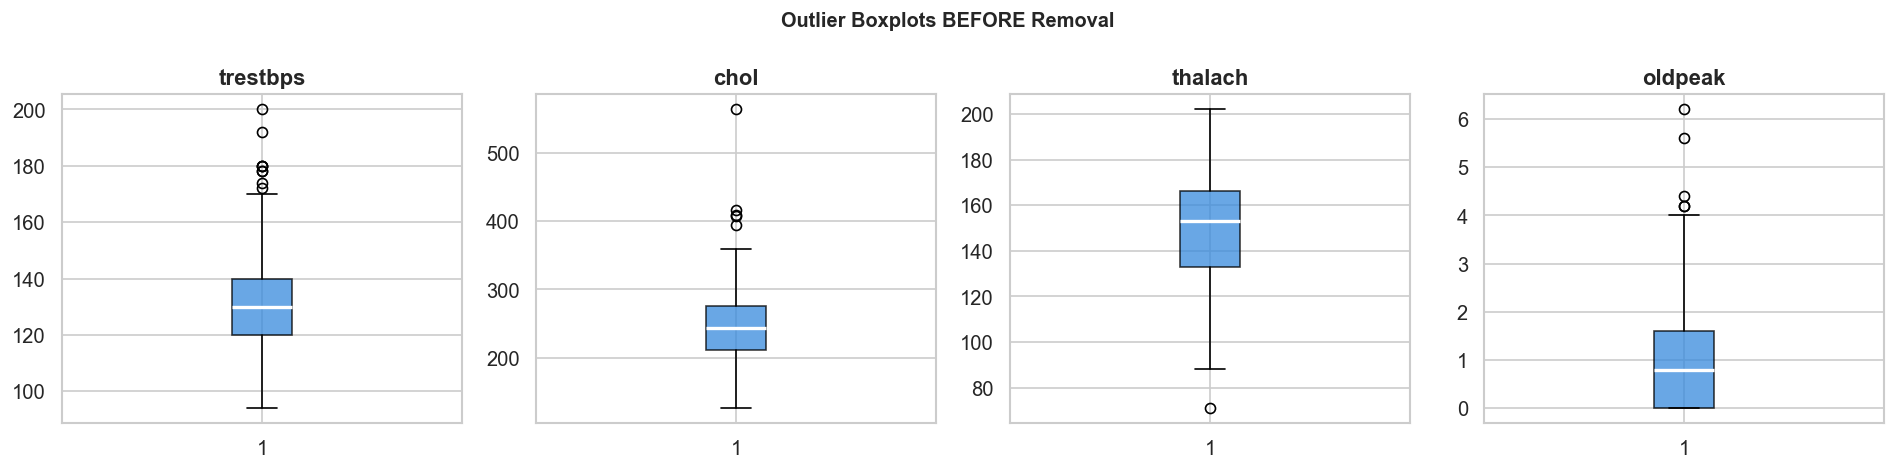

In [5]:
# Visualise outliers before removal
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    bp = ax.boxplot(df[col], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#378add')
    bp['boxes'][0].set_alpha(0.75)
    ax.set_title(col, fontweight='bold')
plt.suptitle('Outlier Boxplots BEFORE Removal', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# Remove outliers
df_clean = df.copy()
rows_before = len(df_clean)

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    print(f'  {col:<12}: removed {before - len(df_clean)} rows')

rows_after = len(df_clean)
print(f'\nRows before outlier removal: {rows_before}')
print(f'Rows after outlier removal:  {rows_after}')
print(f'Total rows removed: {rows_before - rows_after}')
print(f'\n Dataset still has {rows_after} patients — enough for modelling.')
print(f'Class balance after: {dict(df_clean["condition"].value_counts())}')

  trestbps    : removed 9 rows
  chol        : removed 5 rows
  thalach     : removed 1 rows
  oldpeak     : removed 4 rows

Rows before outlier removal: 297
Rows after outlier removal:  278
Total rows removed: 19

 Dataset still has 278 patients — enough for modelling.
Class balance after: {0: 154, 1: 124}


## Step 4 — Feature Engineering

We create 5 new features based on clinical domain knowledge.
These go beyond the raw measurements and capture meaningful medical relationships.

In [7]:
df_feat = df_clean.copy()

# ── Feature 1: Age Group ────────────────────────────────────────────────
# Clinical risk tiers used in cardiology practice
df_feat['age_group'] = pd.cut(
    df_feat['age'],
    bins=[0, 45, 60, 100],
    labels=[0, 1, 2]   # 0=young(<45), 1=middle(45-60), 2=senior(60+)
).astype(int)
print('Feature 1: age_group')
print(df_feat['age_group'].value_counts().sort_index())

# ── Feature 2: Heart Rate Reserve Percentage ───────────────────────────
# Max heart rate as % of age-predicted maximum (220 - age)
# Lower % = heart not responding well under exercise stress
df_feat['thalach_pct_max'] = (df_feat['thalach'] / (220 - df_feat['age'])).round(4)
print('\nFeature 2: thalach_pct_max')
print(df_feat['thalach_pct_max'].describe().round(3))

# ── Feature 3: Cholesterol-to-Age Ratio ────────────────────────────────
# Older patients tolerate high cholesterol less well
df_feat['chol_age_ratio'] = (df_feat['chol'] / df_feat['age']).round(4)
print('\nFeature 3: chol_age_ratio')
print(df_feat['chol_age_ratio'].describe().round(3))

# ── Feature 4: ST Depression × Slope Interaction ──────────────────────
# Combines two related ECG features into one risk signal
df_feat['oldpeak_slope'] = (df_feat['oldpeak'] * (df_feat['slope'] + 1)).round(4)
print('\nFeature 4: oldpeak_slope')
print(df_feat['oldpeak_slope'].describe().round(3))

# ── Feature 5: High Risk Compound Flag ────────────────────────────────
# Exercise angina AND significant ST depression together = strong risk signal
df_feat['high_risk_flag'] = ((df_feat['exang'] == 1) & (df_feat['oldpeak'] > 1.0)).astype(int)
print('\nFeature 5: high_risk_flag')
print(df_feat['high_risk_flag'].value_counts())

print(f'\n✅ Feature engineering done. Shape: {df_feat.shape}')
print(f'New features added: age_group, thalach_pct_max, chol_age_ratio, oldpeak_slope, high_risk_flag')

Feature 1: age_group
age_group
0     61
1    147
2     70
Name: count, dtype: int64

Feature 2: thalach_pct_max
count    278.000
mean       0.904
std        0.126
min        0.540
25%        0.835
50%        0.929
75%        1.000
max        1.140
Name: thalach_pct_max, dtype: float64

Feature 3: chol_age_ratio
count    278.000
mean       4.601
std        1.078
min        2.099
25%        3.834
50%        4.464
75%        5.292
max        8.231
Name: chol_age_ratio, dtype: float64

Feature 4: oldpeak_slope
count    278.000
mean       1.841
std        2.272
min        0.000
25%        0.000
50%        0.950
75%        3.000
max       10.800
Name: oldpeak_slope, dtype: float64

Feature 5: high_risk_flag
high_risk_flag
0    224
1     54
Name: count, dtype: int64

✅ Feature engineering done. Shape: (278, 19)
New features added: age_group, thalach_pct_max, chol_age_ratio, oldpeak_slope, high_risk_flag


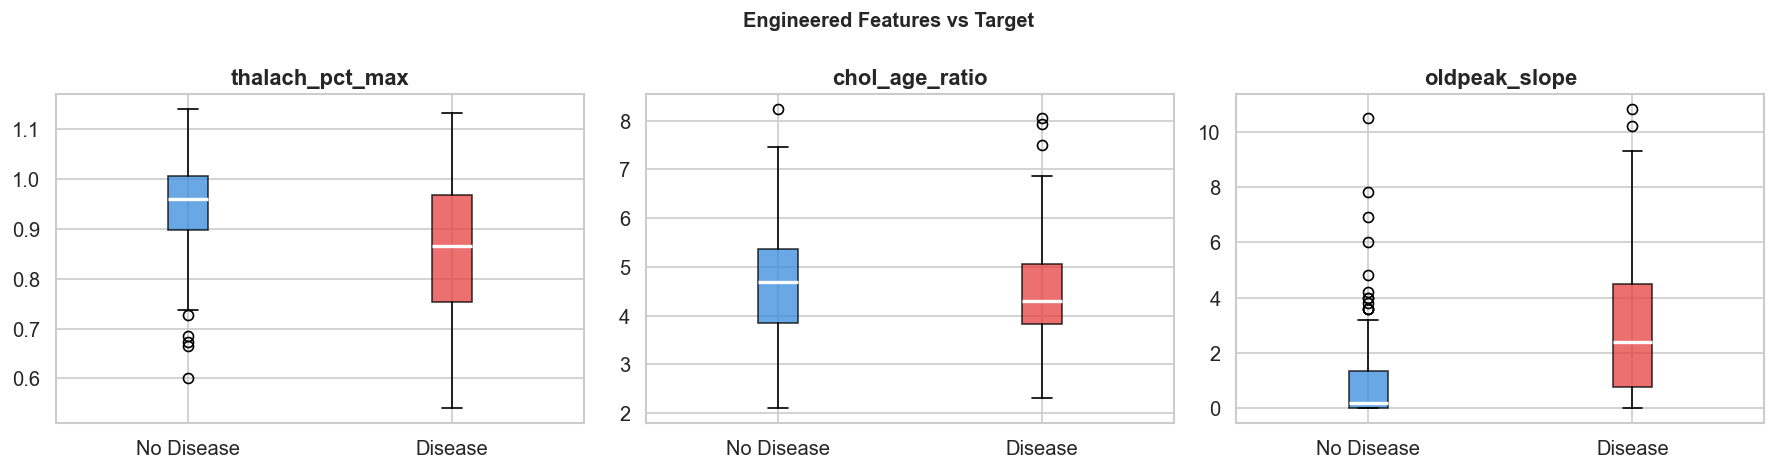

In [8]:
# Visualise new features vs target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['thalach_pct_max', 'chol_age_ratio', 'oldpeak_slope']):
    bp = ax.boxplot(
        [df_feat[df_feat['condition']==0][col],
         df_feat[df_feat['condition']==1][col]],
        patch_artist=True,
        labels=['No Disease', 'Disease'],
        medianprops=dict(color='white', linewidth=2)
    )
    for patch, c in zip(bp['boxes'], ['#378add', '#e84040']):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_title(col, fontweight='bold')

plt.suptitle('Engineered Features vs Target', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../App/static/plot_engineered_features.png', bbox_inches='tight')
plt.show()

## Step 5 — Save Cleaned Dataset

In [9]:
# Final check before saving
print('── Final Dataset Check ─────────────────────')
print(f'Shape         : {df_feat.shape}')
print(f'Missing values: {df_feat.isnull().sum().sum()}')
print(f'Duplicates    : {df_feat.duplicated().sum()}')
print(f'Class balance : {dict(df_feat["condition"].value_counts())}')
print(f'\nColumns in cleaned dataset:')
for col in df_feat.columns:
    print(f'  {col}')

# Save
df_feat.to_csv('../Data/heart_cleaned.csv', index=False)
print(f'\n✅ Cleaned dataset saved → Data/heart_cleaned.csv')
print('   Next step → Run 03_Modelling.ipynb')

── Final Dataset Check ─────────────────────
Shape         : (278, 19)
Missing values: 0
Duplicates    : 0
Class balance : {0: 154, 1: 124}

Columns in cleaned dataset:
  age
  sex
  cp
  trestbps
  chol
  fbs
  restecg
  thalach
  exang
  oldpeak
  slope
  ca
  thal
  condition
  age_group
  thalach_pct_max
  chol_age_ratio
  oldpeak_slope
  high_risk_flag

✅ Cleaned dataset saved → Data/heart_cleaned.csv
   Next step → Run 03_Modelling.ipynb


In [10]:
# Quick comparison: raw vs cleaned
print('── Before vs After Summary ─────────────────')
print(f'  Raw dataset shape    : {df_raw.shape}')
print(f'  Cleaned dataset shape: {df_feat.shape}')
print(f'  Rows removed (outliers): {df_raw.shape[0] - df_feat.shape[0]}')
print(f'  New features added: 5')
print(f'  Missing values: 0 → 0 (none throughout)')
df_feat.head()

── Before vs After Summary ─────────────────
  Raw dataset shape    : (297, 14)
  Cleaned dataset shape: (278, 19)
  Rows removed (outliers): 19
  New features added: 5
  Missing values: 0 → 0 (none throughout)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition,age_group,thalach_pct_max,chol_age_ratio,oldpeak_slope,high_risk_flag
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0,2,0.8675,3.3913,0.2,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0,2,1.0000,3.4638,1.8,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0,2,0.7403,3.4242,7.8,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1,2,1.1226,4.3385,2.8,0
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0,2,0.9231,3.2969,3.6,1
